# **Laboratorio 2 - Complejidad y búsqueda de hiperparámetros**

Laura Sanchez Bernal - 202411353

Baruc Jeronimo Triana Bastidas - 202416093


## 1. Importación de las librerías

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample
import matplotlib.pyplot as plt


## 2. Carga de los datos

Se trabaja con la versión del conjunto de datos ya limpia y preparada en el Laboratorio 1 (`datatransf`), exportada como CSV. Por tanto, en este laboratorio el énfasis está en el modelado, la validación y el análisis del desempeño predictivo, no en la exploración ni el procesamiento de los datos.

In [34]:
datatransf = pd.read_csv('./data/datos_limpios_lab1.csv')
data = datatransf.copy()
data.head()


,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,amplitud_presion,amplitud_humedad,amplitud_viento,velocidad_resultante
0,999.1456,996.50,1000.87,1.3993,91.0860,0.875000,94.8,1.7650,0.7786,0.05,...,2009.0,1.0,invierno,enero,S,-2.12,4.37,93.925,1.509641,0.362487
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,0.22,...,2009.0,2.0,invierno,julio,NE,-0.82,4.72,9.700,3.650000,0.564057
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,0.12,...,2009.0,3.0,invierno,enero,SO,-0.63,9.44,45.510,3.520000,0.875522
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,0.54,...,2009.0,4.0,invierno,enero,SO,-1.44,7.81,NaN,1.914415,1.534270
4,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,1.00,...,2009.0,5.0,NaN,enero,N,-10.88,NaN,18.600,6.810000,2.643171


## 3. Partición de los datos

Se mantiene el mismo `test_size` y `random_state` utilizados en el Laboratorio 1, de manera que los resultados de ambos laboratorios sean comparables.

In [35]:
target = "temp_max_manana"
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1801, 29)
X_test: (601, 29)


## 4. Identificación de variables y preprocesamiento base

Se conservan las mismas variables categóricas identificadas en el Modelo 2 del Laboratorio 1 (el modelo seleccionado, que incluye las variables de ingeniería de características). Las variables numéricas se imputan con la mediana (por la presencia de outliers) y se escalan; las categóricas se imputan con la moda y se codifican mediante One-Hot Encoding.

In [36]:
categorical_features = ['estacion_anio', 'mes', 'sector_viento']

numeric_features = [
    columna for columna in X_train.columns
    if columna not in categorical_features
]

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))


Variables numéricas: 26
Variables categóricas: 3


In [37]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# Preprocesamiento base (sin transformación polinomial), usado en Ridge y Lasso
numeric_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_base = ColumnTransformer(transformers=[
    ("num", numeric_transformer_base, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


In [38]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

## 5. Actividad 1 — Modelo de regresión polinomial

Se incorpora PolynomialFeatures dentro del pipeline numérico después de la imputación y el escalamiento. La búsqueda de hiperparámetros se realiza con GridSearchCV, explorando el grado del polinomio y distintas estrategias de escalamiento.

In [39]:
numeric_transformer_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
])

preprocessor_polinomial = ColumnTransformer(transformers=[
    ("num", numeric_transformer_polinomial, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

pipeline_regresion_polinomial = Pipeline(steps=[
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression()),
])


### Modelo de grado 2 (referencia inicial)

In [40]:
pipeline_regresion_polinomial.fit(X_train, y_train)

modelo = pipeline_regresion_polinomial.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))

y_train_pred = pipeline_regresion_polinomial.predict(X_train)
print('------ Regresión polinomial grado 2 - Entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"R²: {r2_score(y_train, y_train_pred):.4f}")

y_test_pred = pipeline_regresion_polinomial.predict(X_test)
print('------ Regresión polinomial grado 2 - Test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"R²: {r2_score(y_test, y_test_pred):.4f}")


Número de coeficientes: 398
------ Regresión polinomial grado 2 - Entrenamiento ----
RMSE: 4.1972
MAE: 3.1122
R²: 0.7964
------ Regresión polinomial grado 2 - Test ----
RMSE: 34.1516
MAE: 6.0342
R²: -13.6241


### Modelo de grado 3 (para observar el efecto de la complejidad)

In [41]:
numeric_transformer_g3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
])
preprocessor_g3 = ColumnTransformer(transformers=[
    ("num", numeric_transformer_g3, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
pipeline_g3 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g3),
    ("modelo", LinearRegression()),
])

pipeline_g3.fit(X_train, y_train)
print("Número de coeficientes:", len(pipeline_g3.named_steps["modelo"].coef_))

y_train_pred_g3 = pipeline_g3.predict(X_train)
y_test_pred_g3 = pipeline_g3.predict(X_test)
print('------ Grado 3 - Entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_g3)):.4f}, R²: {r2_score(y_train, y_train_pred_g3):.4f}")
print('------ Grado 3 - Test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_g3)):.4f}, R²: {r2_score(y_test, y_test_pred_g3):.4f}")


Número de coeficientes: 3674
------ Grado 3 - Entrenamiento ----
RMSE: 0.2538, R²: 0.9993
------ Grado 3 - Test ----
RMSE: 1146.6104, R²: -16483.6403


### Búsqueda de hiperparámetros (grado + estrategia de escalamiento)

El enunciado pide explorar tanto el grado del polinomio como distintas estrategias de escalamiento dentro del pipeline.

In [42]:
param_grid_poly = {
    "preprocesamiento__num__polynomial__degree": [1, 2],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
}

grid_poly = GridSearchCV(
    estimator=pipeline_regresion_polinomial,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


In [43]:
%%time
grid_poly.fit(X_train, y_train)
print("Mejor configuración:", grid_poly.best_params_)


Mejor configuración: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': RobustScaler()}
CPU times: user 545 ms, sys: 1.1 s, total: 1.64 s
Wall time: 241 ms


In [44]:
mejor_modelo_polinomial = grid_poly.best_estimator_
y_test_pred = mejor_modelo_polinomial.predict(X_test)

print('------ Mejor modelo polinomial - Resultados en test ----')
rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_poly_test = mean_absolute_error(y_test, y_test_pred)
r2_poly_test = r2_score(y_test, y_test_pred)
print(f"RMSE: {rmse_poly_test:.4f}")
print(f"MAE: {mae_poly_test:.4f}")
print(f"R²: {r2_poly_test:.4f}")


------ Mejor modelo polinomial - Resultados en test ----
RMSE: 6.6334
MAE: 5.0913
R²: 0.4483


## 6. Actividad 2 — Curvas de validación

Se utiliza `validation_curve` para observar cómo cambia el error del modelo (en entrenamiento y en validación cruzada) a medida que aumenta el grado de la transformación polinomial. Esto permite visualizar el trade-off sesgo-varianza: un grado bajo genera alto sesgo, mientras que un grado alto genera alta varianza (sobreajuste).

Se evalúan los grados [1, 2, 3] para observar cómo cambia el comportamiento del modelo al aumentar su complejidad. No se consideran grados mayores porque generarían un número excesivo de combinaciones polinomiales.

In [45]:
param_range = [1, 2, 3]

train_scores, cv_scores = validation_curve(
    estimator=pipeline_regresion_polinomial,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=param_range,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores
cv_rmse = -cv_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
cv_rmse_mean = cv_rmse.mean(axis=1)
cv_rmse_std = cv_rmse.std(axis=1)

print("RMSE promedio en entrenamiento:", train_rmse_mean)
print("RMSE promedio en validación cruzada:", cv_rmse_mean)
print("Desviación estándar en validación cruzada:", cv_rmse_std)


RMSE promedio en entrenamiento: [6.52334387 4.04273734 0.00907985]
RMSE promedio en validación cruzada: [  6.80519253  11.70837297 180.67696042]
Desviación estándar en validación cruzada: [  0.48356142   4.50001522 119.51626934]


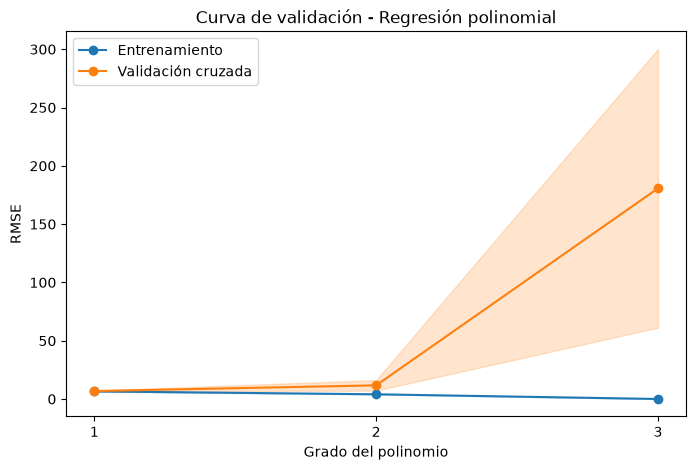

In [46]:
plt.figure(figsize=(8,5))

plt.plot(param_range, train_rmse_mean, 'o-', color='tab:blue', label='Entrenamiento')
plt.fill_between(param_range, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std,
                  alpha=0.2, color='tab:blue')

plt.plot(param_range, cv_rmse_mean, 'o-', color='tab:orange', label='Validación cruzada')
plt.fill_between(param_range, cv_rmse_mean - cv_rmse_std, cv_rmse_mean + cv_rmse_std,
                  alpha=0.2, color='tab:orange')

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validación - Regresión polinomial')
plt.xticks(param_range)
plt.legend()
plt.show()


El sobreajuste empieza a evidenciarse en el grado 2, ya que el RMSE de entrenamiento disminuye mientras que el de validación cruzada aumenta. En el grado 3 este efecto es mucho más fuerte: el error de entrenamiento es casi cero, pero el error de validación y su variabilidad aumentan considerablemente, lo que indica alta varianza.

## 7. Actividad 3 — Regresión regularizada (Ridge y Lasso)

Se utilizan los mismos 5 folds de validación cruzada definidos anteriormente para comparar los modelos de forma consistente. Se construyen los pipelines de Ridge y Lasso, explorando distintos valores del hiperparámetro alpha y distintas estrategias de escalamiento. Como referencia, también se entrena un modelo lineal sin regularización con el mismo preprocesamiento base.

### Modelo sin regularización (referencia)

In [47]:
pipeline_lineal = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", LinearRegression()),
])
pipeline_lineal.fit(X_train, y_train)

y_pred_lineal_train = pipeline_lineal.predict(X_train)
y_pred_lineal_test = pipeline_lineal.predict(X_test)

rmse_lineal_train = np.sqrt(mean_squared_error(y_train, y_pred_lineal_train))
mae_lineal_train = mean_absolute_error(y_train, y_pred_lineal_train)
r2_lineal_train = r2_score(y_train, y_pred_lineal_train)

rmse_lineal_test = np.sqrt(mean_squared_error(y_test, y_pred_lineal_test))
mae_lineal_test = mean_absolute_error(y_test, y_pred_lineal_test)
r2_lineal_test = r2_score(y_test, y_pred_lineal_test)

print(f"Train -> RMSE: {rmse_lineal_train:.4f}, MAE: {mae_lineal_train:.4f}, R²: {r2_lineal_train:.4f}")
print(f"Test  -> RMSE: {rmse_lineal_test:.4f}, MAE: {mae_lineal_test:.4f}, R²: {r2_lineal_test:.4f}")


Train -> RMSE: 6.5501, MAE: 5.0005, R²: 0.5040
Test  -> RMSE: 6.6334, MAE: 5.0913, R²: 0.4483


### Ridge (L2)

In [48]:
pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 50, 100],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge, param_grid=param_grid_ridge,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [49]:
%%time
grid_ridge.fit(X_train, y_train)
print("Mejor configuración Ridge:", grid_ridge.best_params_)

Mejor configuración Ridge: {'modelo__alpha': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 586 ms, sys: 1.61 s, total: 2.2 s
Wall time: 346 ms


In [50]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
mae_ridge_train = mean_absolute_error(y_train, y_pred_ridge_train)
r2_ridge_train = r2_score(y_train, y_pred_ridge_train)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge_test)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

print(f"Train -> RMSE: {rmse_ridge_train:.4f}, MAE: {mae_ridge_train:.4f}, R²: {r2_ridge_train:.4f}")
print(f"Test  -> RMSE: {rmse_ridge_test:.4f}, MAE: {mae_ridge_test:.4f}, R²: {r2_ridge_test:.4f}")


Train -> RMSE: 6.5622, MAE: 5.0095, R²: 0.5022
Test  -> RMSE: 6.6074, MAE: 5.0834, R²: 0.4526


#### Revisión de coeficientes — Ridge

In [51]:
feature_names_ridge = best_ridge.named_steps["preprocesamiento"].get_feature_names_out()
coefs_ridge = best_ridge.named_steps["modelo"].coef_

coef_ridge_df = pd.DataFrame({
    "Variable": feature_names_ridge,
    "coef_ridge": coefs_ridge
})
coef_ridge_df["coef_ridge"] = coef_ridge_df["coef_ridge"].round(4)
coef_ridge_df = coef_ridge_df.sort_values("coef_ridge", key=abs, ascending=False)
coef_ridge_df.head(15)


,Variable,coef_ridge
7,num__humedad_desv,18.4424
25,num__velocidad_resultante,-12.2172
3,num__presion_desv,-12.0058
9,num__viento_min,-9.6088
4,num__humedad_media,-8.3409
15,num__rafaga_desv,-7.6512
21,num__dia_del_anio,7.5311
16,num__viento_norte,-7.5282
11,num__viento_desv,-6.4608
1,num__presion_min,-4.9882


### Lasso (L1)

In [52]:
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", Lasso(max_iter=5000)),
])

param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso, param_grid=param_grid_lasso,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [53]:
%%time
grid_lasso.fit(X_train, y_train)
print("Mejor configuración Lasso:", grid_lasso.best_params_)

Mejor configuración Lasso: {'modelo__alpha': 0.01, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 113 ms, sys: 22.5 ms, total: 136 ms
Wall time: 253 ms


**Nota:** si el mejor `alpha` encontrado cae justo en el borde del rango explorado (el más pequeño o el más grande de la lista), amplía `param_grid_lasso` en esa dirección y vuelve a correr — significa que el óptimo real podría estar fuera del rango probado.

In [54]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

rmse_lasso_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
mae_lasso_train = mean_absolute_error(y_train, y_pred_lasso_train)
r2_lasso_train = r2_score(y_train, y_pred_lasso_train)

rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mae_lasso_test = mean_absolute_error(y_test, y_pred_lasso_test)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)

print(f"Train -> RMSE: {rmse_lasso_train:.4f}, MAE: {mae_lasso_train:.4f}, R²: {r2_lasso_train:.4f}")
print(f"Test  -> RMSE: {rmse_lasso_test:.4f}, MAE: {mae_lasso_test:.4f}, R²: {r2_lasso_test:.4f}")


Train -> RMSE: 6.6049, MAE: 5.0388, R²: 0.4957
Test  -> RMSE: 6.6148, MAE: 5.0873, R²: 0.4514


#### Revisión de coeficientes — Lasso (variables llevadas a cero)

In [55]:
feature_names_lasso = best_lasso.named_steps["preprocesamiento"].get_feature_names_out()
coefs_lasso = best_lasso.named_steps["modelo"].coef_

coef_lasso_df = pd.DataFrame({
    "Variable": feature_names_lasso,
    "coef_lasso": coefs_lasso
})
coef_lasso_df["coef_lasso"] = coef_lasso_df["coef_lasso"].round(4)

n_ceros = (coefs_lasso == 0).sum()
print(f"Variables llevadas a cero por Lasso: {n_ceros} de {len(coef_lasso_df)}")

coef_lasso_df_sorted = coef_lasso_df.sort_values("coef_lasso", key=abs, ascending=False)
coef_lasso_df_sorted.head(15)


Variables llevadas a cero por Lasso: 8 de 47


,Variable,coef_lasso
7,num__humedad_desv,18.9175
3,num__presion_desv,-10.5830
25,num__velocidad_resultante,-9.1087
4,num__humedad_media,-8.4073
21,num__dia_del_anio,7.5723
16,num__viento_norte,-7.4639
6,num__humedad_max,-5.9033
9,num__viento_min,-5.6364
30,cat__mes_diciembre,-3.7551
10,num__viento_max,3.3035


In [56]:
print("Variables eliminadas (coeficiente = 0):")
coef_lasso_df.loc[coefs_lasso == 0, "Variable"].tolist()

Variables eliminadas (coeficiente = 0):


['num__presion_media',
 'num__presion_min',
 'num__viento_media',
 'num__viento_desv',
 'num__rafaga_min',
 'num__registros_del_dia',
 'num__amplitud_presion',
 'cat__sector_viento_N']

### Comparación: sin regularización vs. Ridge vs. Lasso

In [57]:
comparacion_regularizacion = pd.DataFrame([
    {"Modelo": "Sin regularización", "RMSE_train": rmse_lineal_train, "MAE_train": mae_lineal_train, "R2_train": r2_lineal_train,
     "RMSE_test": rmse_lineal_test, "MAE_test": mae_lineal_test, "R2_test": r2_lineal_test},
    {"Modelo": "Ridge", "RMSE_train": rmse_ridge_train, "MAE_train": mae_ridge_train, "R2_train": r2_ridge_train,
     "RMSE_test": rmse_ridge_test, "MAE_test": mae_ridge_test, "R2_test": r2_ridge_test},
    {"Modelo": "Lasso", "RMSE_train": rmse_lasso_train, "MAE_train": mae_lasso_train, "R2_train": r2_lasso_train,
     "RMSE_test": rmse_lasso_test, "MAE_test": mae_lasso_test, "R2_test": r2_lasso_test},
])
comparacion_regularizacion


,Modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Sin regularización,6.550084,5.000529,0.504040,6.633433,5.091345,0.448273
1,Ridge,6.562201,5.009496,0.502204,6.607436,5.083390,0.452589
2,Lasso,6.604868,5.038833,0.495709,6.614782,5.087347,0.451371


La regularización redujo la magnitud de los coeficientes y produjo resultados ligeramente mejores que el modelo sin regularización. Ridge obtuvo el menor RMSE en test (6.6074), aunque Lasso tuvo un resultado muy cercano (6.6148). Además, Lasso llevó 8 de las 47 variables a coeficiente cero, entre ellas presión media, presión mínima, viento medio y amplitud de presión. Esto muestra cómo Lasso puede simplificar el modelo al eliminar variables con poca contribución, facilitando su interpretación.

## 8. Actividad 4 — Modelo de regresión polinomial regularizado

Se combina la generación de características polinomiales con un modelo regularizado. Se utiliza Ridge por su mayor estabilidad numérica al trabajar con el número elevado de variables que genera `PolynomialFeatures`. La búsqueda de hiperparámetros explora el grado del polinomio, el parámetro de penalización y distintas estrategias de escalamiento.

Se limita la búsqueda a grados [1, 2], ya que en la Actividad 1 el grado 3 mostró un sobreajuste muy alto y generó un número considerablemente mayor de características.


In [58]:
numeric_transformer_poly_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
])

preprocessor_poly_reg = ColumnTransformer(transformers=[
    ("num", numeric_transformer_poly_reg, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

pipeline_poly_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_poly_reg),
    ("modelo", Ridge()),
])

param_grid_poly_ridge = {
    "preprocesamiento__num__polynomial__degree": [1, 2],
    "modelo__alpha": [0.1, 1, 10, 50, 100, 200, 500],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_poly_ridge = GridSearchCV(
    estimator=pipeline_poly_ridge, param_grid=param_grid_poly_ridge,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [59]:
%%time
grid_poly_ridge.fit(X_train, y_train)
print("Mejor configuración:", grid_poly_ridge.best_params_)


Mejor configuración: {'modelo__alpha': 1, 'preprocesamiento__num__polynomial__degree': 2, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 323 ms, sys: 43 ms, total: 366 ms
Wall time: 609 ms


In [60]:
best_poly_ridge = grid_poly_ridge.best_estimator_

y_pred_poly_ridge_train = best_poly_ridge.predict(X_train)
y_pred_poly_ridge_test = best_poly_ridge.predict(X_test)

rmse_poly_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_poly_ridge_train))
mae_poly_ridge_train = mean_absolute_error(y_train, y_pred_poly_ridge_train)
r2_poly_ridge_train = r2_score(y_train, y_pred_poly_ridge_train)

rmse_poly_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge_test))
mae_poly_ridge_test = mean_absolute_error(y_test, y_pred_poly_ridge_test)
r2_poly_ridge_test = r2_score(y_test, y_pred_poly_ridge_test)

print(f"Train -> RMSE: {rmse_poly_ridge_train:.4f}, MAE: {mae_poly_ridge_train:.4f}, R²: {r2_poly_ridge_train:.4f}")
print(f"Test  -> RMSE: {rmse_poly_ridge_test:.4f}, MAE: {mae_poly_ridge_test:.4f}, R²: {r2_poly_ridge_test:.4f}")


Train -> RMSE: 4.8968, MAE: 3.6104, R²: 0.7228
Test  -> RMSE: 5.1940, MAE: 3.7638, R²: 0.6617


In [61]:
rmse_cv_poly_ridge = -cross_val_score(
    best_poly_ridge, X_train, y_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

mae_cv_poly_ridge = -cross_val_score(
    best_poly_ridge, X_train, y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

r2_cv_poly_ridge = cross_val_score(
    best_poly_ridge, X_train, y_train,
    cv=kfold,
    scoring="r2"
)

print(f"RMSE CV: {rmse_cv_poly_ridge.mean():.4f} ± {rmse_cv_poly_ridge.std():.4f}")
print(f"MAE CV: {mae_cv_poly_ridge.mean():.4f} ± {mae_cv_poly_ridge.std():.4f}")
print(f"R² CV: {r2_cv_poly_ridge.mean():.4f} ± {r2_cv_poly_ridge.std():.4f}")

RMSE CV: 5.5014 ± 0.5589
MAE CV: 4.0084 ± 0.1980
R² CV: 0.6469 ± 0.0573


La regularización permitió controlar considerablemente el sobreajuste del modelo polinomial. El modelo Polinomial + Ridge obtuvo en validación cruzada un RMSE promedio de 5.50, un MAE de 4.01 y un R² de 0.65, con una variabilidad moderada entre los folds. Además, en test alcanzó un RMSE de 5.19 y un R² de 0.66, mientras que el modelo de grado 2 sin regularización había obtenido un RMSE de 34.15 y un R² negativo. Esto muestra que la penalización permite aprovechar la mayor complejidad del modelo sin perder su capacidad de generalización.


## 9. Actividad 5 — Comparación y selección del mejor modelo

Se comparan los tres modelos construidos en las Actividades 1, 3 y 4, considerando no solo el desempeño promedio sino también su estabilidad (desviación estándar) mediante validación cruzada sobre el conjunto de entrenamiento.

In [62]:
modelos_finales = {
    "Polinomial (Act. 1)": mejor_modelo_polinomial,
    "Ridge (Act. 3)": best_ridge,
    "Lasso (Act. 3)": best_lasso,
    "Polinomial + Ridge (Act. 4)": best_poly_ridge,
}

resumen_filas = []
for nombre, modelo in modelos_finales.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring="neg_root_mean_squared_error")
    rmse_cv = -scores
    y_pred_test = modelo.predict(X_test)
    resumen_filas.append({
        "Modelo": nombre,
        "RMSE_CV_promedio": rmse_cv.mean(),
        "RMSE_CV_std": rmse_cv.std(),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE_test": mean_absolute_error(y_test, y_pred_test),
        "R2_test": r2_score(y_test, y_pred_test),
    })

tabla_comparativa = pd.DataFrame(resumen_filas).sort_values("RMSE_CV_promedio")
tabla_comparativa


,Modelo,RMSE_CV_promedio,RMSE_CV_std,RMSE_test,MAE_test,R2_test
3,Polinomial + Ridge (Act. 4),5.501413,0.558912,5.194030,3.763766,0.661735
1,Ridge (Act. 3),6.775228,0.478639,6.607436,5.083390,0.452589
2,Lasso (Act. 3),6.779968,0.471786,6.614782,5.087347,0.451371
0,Polinomial (Act. 1),6.805193,0.483561,6.633433,5.091345,0.448273


Se selecciona el modelo Polinomial + Ridge porque obtuvo el menor RMSE promedio en validación cruzada (5.50) y también el mejor desempeño en test, con un RMSE de 5.19 y un R² de 0.66. Aunque su desviación estándar es ligeramente mayor que la de los otros modelos, la mejora en desempeño es considerable. Además, Ridge ayuda a controlar la complejidad introducida por las características polinomiales.

In [63]:
modelo_final = best_poly_ridge


## 10. Actividad 6 — Intervalos de confianza (bootstrapping)

Se aplica bootstrapping sobre el conjunto de prueba para estimar la variabilidad del RMSE y construir un intervalo de confianza del 95%. Se realizan 1000 iteraciones; en cada una se genera una muestra con reemplazo a partir de los datos de prueba, se calculan las predicciones con el modelo ya entrenado y se obtiene el RMSE correspondiente.

Media del RMSE: 5.2062
Desviación estándar del RMSE: 0.3359
Intervalo de confianza del RMSE (95%): [4.6252, 5.9100]

Media del MAE: 3.7739
Desviación estándar del MAE: 0.1493
Intervalo de confianza del MAE (95%): [3.4740, 4.0746]

Media del R²: 0.6590
Desviación estándar del R²: 0.0374
Intervalo de confianza del R² (95%): [0.5801, 0.7213]


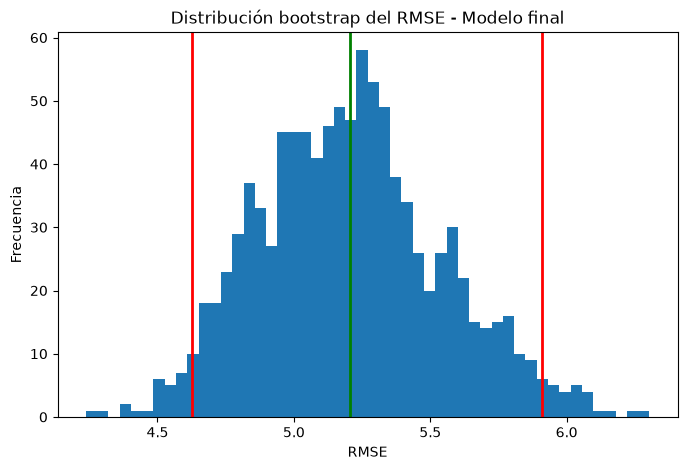

In [64]:
n_iterations = 1000

rmse_stats = []
mae_stats = []
r2_stats = []

for i in range(n_iterations):
    X_resample, y_resample = resample(
        X_test,
        y_test,
        replace=True,
        n_samples=len(X_test)
    )

    pred = modelo_final.predict(X_resample)

    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    mae = mean_absolute_error(y_resample, pred)
    r2 = r2_score(y_resample, pred)

    rmse_stats.append(rmse)
    mae_stats.append(mae)
    r2_stats.append(r2)

alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + (1.0 - alpha) / 2.0) * 100

rmse_lower = np.percentile(rmse_stats, p_lower)
rmse_upper = np.percentile(rmse_stats, p_upper)

mae_lower = np.percentile(mae_stats, p_lower)
mae_upper = np.percentile(mae_stats, p_upper)

r2_lower = np.percentile(r2_stats, p_lower)
r2_upper = np.percentile(r2_stats, p_upper)

print(f"Media del RMSE: {np.mean(rmse_stats):.4f}")
print(f"Desviación estándar del RMSE: {np.std(rmse_stats):.4f}")
print(f"Intervalo de confianza del RMSE (95%): [{rmse_lower:.4f}, {rmse_upper:.4f}]")

print(f"\nMedia del MAE: {np.mean(mae_stats):.4f}")
print(f"Desviación estándar del MAE: {np.std(mae_stats):.4f}")
print(f"Intervalo de confianza del MAE (95%): [{mae_lower:.4f}, {mae_upper:.4f}]")

print(f"\nMedia del R²: {np.mean(r2_stats):.4f}")
print(f"Desviación estándar del R²: {np.std(r2_stats):.4f}")
print(f"Intervalo de confianza del R² (95%): [{r2_lower:.4f}, {r2_upper:.4f}]")

plt.figure(figsize=(8, 5))
plt.hist(rmse_stats, bins=50)
plt.axvline(rmse_lower, color="red", linewidth=2)
plt.axvline(np.mean(rmse_stats), color="green", linewidth=2)
plt.axvline(rmse_upper, color="red", linewidth=2)
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del RMSE - Modelo final")
plt.show()

Los resultados del bootstrap muestran una variabilidad moderada en el desempeño del modelo. El RMSE presenta un intervalo de confianza del 95% entre 4.63 y 5.91, mientras que el MAE se encuentra entre 3.47 y 4.07 y el R² entre 0.58 y 0.72. Esto sugiere que el modelo mantiene un desempeño relativamente estable ante diferentes muestras del conjunto de prueba. Estos intervalos describen la variabilidad de las métricas de desempeño y no la incertidumbre de una predicción individual.

## 11. Análisis de resultados

### Análisis cuantitativo

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

El modelo con mejor desempeño en test fue Polinomial + Ridge, con un RMSE de 5.1940, un MAE de 3.7638 y un R² de 0.6617. Los modelos Ridge, Lasso y Polinomial de la Actividad 1 obtuvieron resultados similares entre sí, con RMSE alrededor de 6.6, por lo que el modelo polinomial regularizado presentó una mejora clara.

- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

Sí. El modelo Polinomial + Ridge obtuvo tanto el menor RMSE promedio en validación cruzada (5.50) como el menor RMSE en test (5.19). Esto indica que el buen desempeño observado durante la validación también se mantuvo sobre el conjunto de prueba.

- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

No necesariamente. Además del desempeño promedio, también es importante considerar la variabilidad entre los folds. En este caso, Polinomial + Ridge obtuvo el menor RMSE promedio en validación cruzada (5.50), aunque su desviación estándar (0.56) fue ligeramente mayor que la de Ridge y Lasso. Aun así, la mejora en el RMSE promedio es suficientemente grande para preferirlo, ya que mantiene una variabilidad moderada y logra un mejor desempeño general.

- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

A medida que aumenta el grado del polinomio, el error de entrenamiento disminuye, pero el error de validación cruzada aumenta. Con grado 1 ambos errores son similares; en grado 2 el RMSE de entrenamiento baja a aproximadamente 4.04, mientras que el de validación sube a 11.71. En grado 3 el error de entrenamiento es casi cero, pero el RMSE de validación aumenta hasta aproximadamente 180.68 y presenta una variabilidad muy alta. Por esto, el sobreajuste empieza a evidenciarse desde el grado 2 y se vuelve extremo en el grado 3.

- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

La regularización limita la magnitud de los coeficientes y ayuda a evitar que el modelo dependa demasiado de algunas variables. En Ridge los coeficientes se reducen sin eliminar variables, mientras que Lasso puede llevar algunos coeficientes exactamente a cero. En nuestro caso, Lasso eliminó 8 de 47 variables, lo que también simplifica el modelo y facilita su interpretación.

- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

Los intervalos obtenidos sugieren una variabilidad moderada y un desempeño relativamente estable. El RMSE tuvo un intervalo de confianza del 95% entre 4.63 y 5.91, el MAE entre 3.47 y 4.07 y el R² entre 0.58 y 0.72. esto indica que las métricas del modelo se mantienen en rangos similares al cambiar la muestra de prueba, lo que da mayor confianza en su desempeño. Estos intervalos describen la variabilidad de las métricas y no la incertidumbre de una predicción individual.


### Análisis cualitativo

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

Según la magnitud de los coeficientes de Lasso, las variables más relevantes fueron humedad_desv, presion_desv, velocidad_resultante, humedad_media, dia_del_anio y viento_norte. Además, Lasso llevó 8 de las 47 variables a coeficiente cero, por lo que estas no aportaron información adicional al modelo bajo la penalización seleccionada.

- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

En el modelo final, los coeficientes representan la contribución de las variables transformadas y de sus términos polinomiales a la predicción de la temperatura máxima. Sin embargo, como se utilizan escalamiento, interacciones y términos de grado 2, su interpretación individual no es directa en las unidades originales. Por esto, el modelo es más útil para obtener buenas predicciones que para interpretar de forma aislada el efecto de cada variable.

- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. El modelo más preciso fue Polinomial + Ridge, pero su interpretación es más difícil porque utiliza términos polinomiales e interacciones. Lasso es más interpretable porque lleva algunos coeficientes exactamente a cero y reduce el número de variables relevantes. Sin embargo, en este caso el modelo Polinomial + Ridge tuvo una mejora clara en desempeño, por lo que se priorizó la precisión sobre la simplicidad.

- ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

AlpesPlanck podría utilizar el modelo Polinomial + Ridge como apoyo para anticipar la temperatura máxima y mejorar la planeación de sus operaciones. Al tener un mejor desempeño que los modelos más simples, puede servir para tomar decisiones con mayor anticipación, aunque su uso debería complementarse con seguimiento periódico del error del modelo.


- ¿Mayor precisión implica necesariamente mayor valor para la organización?

No necesariamente. Un modelo con menor error puede ser más útil para predecir, pero también puede ser más complejo, costoso de mantener y difícil de interpretar. En este laboratorio, Polinomial + Ridge ofrece el mejor desempeño, pero Lasso resulta más simple e interpretable. Por eso, el valor para la organización depende de equilibrar precisión, estabilidad, interpretabilidad y costo de implementación.

- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

No. Una mayor complejidad puede mejorar el desempeño, pero también aumenta el costo computacional, dificulta la interpretación y puede incrementar el riesgo de sobreajuste. En este laboratorio, el modelo polinomial sin regularización mostró precisamente ese problema, mientras que la regularización permitió aprovechar la complejidad de forma más controlada. Por eso, el valor empresarial depende de que la mejora en desempeño compense la pérdida de simplicidad y el mayor costo de implementación.

### Reflexión conceptual

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

Al aumentar la complejidad, el modelo puede ajustarse mejor a los datos de entrenamiento, pero también aumenta el riesgo de sobreajuste y de perder capacidad de generalización. Esto se observó en los modelos polinomiales de grados 2 y 3 sin regularización. Sin embargo, al aplicar Ridge fue posible utilizar un modelo de grado 2 con mejor desempeño en test y una variabilidad moderada. Por esto, una mayor complejidad puede ser útil siempre que se controle mediante regularización y validación.

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

Pueden existir sesgos si los datos no representan de forma equilibrada todas las condiciones meteorológicas presentes en la realidad o si algunas épocas o condiciones aparecen con mayor frecuencia que otras. También pueden introducirse sesgos durante el modelado por la forma en que se dividen los datos, se seleccionan las variables y se eligen los hiperparámetros. Por esto, es importante evaluar los modelos mediante validación cruzada y no depender únicamente del resultado obtenido en una sola partición.

- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.

Sí. Con una muestra mayor, sería esperable que las estimaciones del desempeño fueran más estables y que la variabilidad entre los folds de validación cruzada disminuyera. Además, disponer de más datos podría ayudar a los modelos más complejos a estimar mejor sus parámetros, aunque no garantiza que desaparezca el sobreajuste. Por eso, aun con más observaciones seguirían siendo necesarias la validación cruzada y la regularización.


## 12. Uso de herramientas de IA generativa

### Declaración del uso

Se utilizó ChatGPT como apoyo para revisar los requerimientos del laboratorio, depurar errores e inconsistencias del notebook, verificar la configuración de los pipelines y la validación cruzada, y mejorar la redacción de algunos análisis. Las decisiones finales, la ejecución del código y la revisión de los resultados fueron realizadas por los estudiantes.

### Prompts utilizados

Se utilizaron algunos pronts como: “Ayúdame a identificar y depurar los warnings que aparecen durante la ejecución sin ocultarlos ni asumir que son errores del modelo.”, "Chat, necesito que me ayudes a revisar porque el ajuste de mi grafica no esta funcional...", "este analisis de resultados tiene sentido frente al modelo de regresion polinomial?"
### Análisis crítico del resultado

La IA fue util ayudando a identificar análisis que habían quedado desactualizados después de modificar los modelos.
Sin embargo, las sugerencias no se tomaron automáticamente. Se verificaron ejecutando nuevamente las celdas y comparando los resultados con el enunciado del laboratorio. Por ejemplo, varias interpretaciones tuvieron que cambiar cuando los nuevos resultados mostraron que el modelo Polinomial + Ridge era el mejor tanto en validación cruzada como en test.
### Aportes propios del estudiante

Se configuro y ejecuto los modelos, se reviso los resultados obtenidos y se tomaron las decisiones finales sobre hiperparámetros, selección del modelo e interpretación de las métricas. También se ajustaron los pipelines, se verificaron los resultados después de cada cambio y se redactaron las conclusiones con base en las ejecuciones finales del notebook. El proceso permitió reforzar conceptos como sobreajuste, regularización, validación cruzada, estabilidad y selección de modelos.